# Task 1 — Ingest PDFs into DuckDB

**What this notebook does:**
1. Smoke-test the parser on one PDF (so you can verify extraction looks right)
2. Run full ingestion across all 1,390 PDFs in `data/raw_pdfs/`
3. Inspect the resulting DuckDB database (row counts, sample queries)
4. Spot-check the parse quality and find any anomalies

**Prerequisites:**
- `pip install -r requirements.txt` already done
- 1,390 PDFs copied into `data/raw_pdfs/`
- `nds_events.xlsx` copied into `data/`

## 0. Setup — make `src/` importable from the notebook

Notebooks live in `notebooks/`, source modules live in `src/`. We add the project root to `sys.path` so imports work cleanly.

In [1]:
import sys
from pathlib import Path

# Project root = parent of the notebooks/ folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ exists:  {(PROJECT_ROOT / 'src').exists()}")

Project root: c:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds
src/ exists:  True


In [2]:
# Auto-reload modules when src/ files change. Edit a parser, rerun a cell — no kernel restart.
%load_ext autoreload
%autoreload 2

## 1. Verify environment

Quick check that all required libs are installed and the data folders exist.

In [3]:
import duckdb
import pdfplumber
import pandas as pd
from src.common.config import RAW_PDF_DIR, DB_PATH, NDS_EVENTS_XLSX

print(f"duckdb     {duckdb.__version__}")
print(f"pdfplumber {pdfplumber.__version__}")
print(f"pandas     {pd.__version__}")
print()

n_pdfs = len(list(RAW_PDF_DIR.glob("*.pdf")))
print(f"Raw PDFs in {RAW_PDF_DIR}: {n_pdfs}")
print(f"NDS events file exists: {NDS_EVENTS_XLSX.exists()}")

duckdb     1.5.2
pdfplumber 0.11.9
pandas     3.0.1

Raw PDFs in C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\data\raw_pdfs: 1000
NDS events file exists: True


## 2. Smoke-test the parser on ONE PDF

Before launching the full ingestion (which writes to the DB), parse a single PDF and inspect the structured output. If anything looks off, you can fix `src/ingestion/sections.py` and rerun this cell — no full re-ingest needed.

In [4]:
from src.ingestion.parse_pdf import parse_pdf

# Pick a sample PDF — defaults to the first one in the folder
sample_pdfs = sorted(RAW_PDF_DIR.glob("*.pdf"))
assert sample_pdfs, f"No PDFs found in {RAW_PDF_DIR}"

sample = sample_pdfs[0]
print(f"Parsing: {sample.name}\n")

parsed = parse_pdf(sample)

Parsing: 15_9_19_A_1980_01_01.pdf



In [5]:
# --- Inspect: header / report fields ---
report = parsed["report"]
populated = {k: v for k, v in report.items() if v is not None}
print(f"Header: {len(populated)}/{len(report)} fields populated\n")
for k, v in populated.items():
    print(f"  {k:35s}: {v!r}")

Header: 19/42 fields populated

  pdf_path                           : 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\data\\raw_pdfs\\15_9_19_A_1980_01_01.pdf'
  pdf_filename                       : '15_9_19_A_1980_01_01.pdf'
  well_prefix                        : '15_9_19_A'
  well_family                        : '15_9_19'
  report_date                        : datetime.date(1980, 1, 1)
  wellbore_id                        : '15/9-19 A'
  status                             : 'normal'
  report_creation_time               : datetime.datetime(2018, 5, 3, 0, 0)
  report_number                      : 1
  spud_date                          : datetime.datetime(1997, 7, 25, 0, 0)
  water_depth_msl_m                  : 84.0
  tight_well                         : True
  hpht                               : True
  date_well_complete                 : datetime.date(1997, 8, 30)
  depth_kickoff_md                   : 2178.0
  depth_kickoff_tvd                  : 13.0
  period_start      

In [6]:
# --- Inspect: operations table ---
ops = parsed["operations"]
print(f"Operations: {len(ops)} rows\n")
for op in ops:
    print(f"  [{op['op_index']}] {op['start_time']}-{op['end_time']} d={op['end_depth_md']}")
    print(f"      activity: {op['main_activity']!r} / {op['sub_activity']!r} / state={op['state']!r}")
    print(f"      remark:   {(op['remark'] or '')[:120]}")
    print()

Operations: 0 rows



In [7]:
# --- Inspect: other sections ---
for section in ["drilling_fluid", "pore_pressure", "survey_station", "lithology", "gas_reading"]:
    rows = parsed[section]
    print(f"{section:20s}: {len(rows)} rows")
    for r in rows[:2]:
        print(f"  {r}")
    print()

drilling_fluid      : 0 rows

pore_pressure       : 0 rows

survey_station      : 5 rows
  {'station_index': 0, 'depth_md': 2200.0, 'depth_tvd': 1638.3, 'inclination_deg': 58.96, 'azimuth_deg': 281.75, 'comment': None}
  {'station_index': 1, 'depth_md': 2210.0, 'depth_tvd': 1643.4, 'inclination_deg': 59.98, 'azimuth_deg': 283.75, 'comment': None}

lithology           : 0 rows

gas_reading         : 0 rows



### 🛑 Checkpoint

Look at the cells above. If extraction looks reasonable for this sample, continue to the full ingestion. If anything looks broken (missing fields, garbled text, wrong row counts), fix `src/ingestion/sections.py` and re-run the smoke-test cell.

Common things to check:
- `wellbore_id` — should be like `"15/9-F-15 A"` not `"Wellbore: 15/9-F-15 A"`
- Each operation should have `main_activity`, `sub_activity`, `state` populated (not all `None`)
- `op_text` should contain meaningful concatenated text

## 3. Run full ingestion across all PDFs

**This is destructive — it drops and recreates all tables.** Takes roughly 5–15 minutes for 1,390 PDFs. The orchestrator catches per-PDF errors so a bad PDF won't kill the run; failures land in the `parse_errors` table for inspection.

In [8]:
from src.ingestion.run_ingestion import run_ingestion

summary = run_ingestion(reset_db=True)
print("\nFinal row counts:")
for table, count in summary.items():
    print(f"  {table:20s} {count:>8,}")

INFO     Ingestion starting. PDF source: C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\data\raw_pdfs

INFO     Found 1000 PDFs.

WARNING  Initializing schema (this drops existing tables):                                                         
         C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\db\drilling.duckdb

INFO     Schema initialized.

parsing PDFs: 100%|██████████| 1000/1000 [11:19<00:00,  1.47pdf/s]


INFO     Ingestion complete. OK=1000, Errors=0.

INFO     Row counts: {'reports': 1000, 'operations': 11199, 'drilling_fluid': 2739, 'pore_pressure': 598,          
         'survey_station': 993, 'lithology': 200, 'gas_reading': 290, 'parse_errors': 0}


Final row counts:
  reports                 1,000
  operations             11,199
  drilling_fluid          2,739
  pore_pressure             598
  survey_station            993
  lithology                 200
  gas_reading               290
  parse_errors                0


## 4. Inspect the database

DuckDB query results return as pandas DataFrames via `.df()`.

In [9]:
from src.common.db import get_connection

with get_connection(read_only=True) as con:
    # Reports per well family
    df = con.execute("""
        SELECT well_family,
               COUNT(*) AS reports,
               MIN(report_date) AS earliest,
               MAX(report_date) AS latest
        FROM reports
        GROUP BY well_family
        ORDER BY reports DESC
    """).df()
df

,well_family,reports,earliest,latest
0,15_9_19,375,1980-01-01,1998-02-05
1,15_9_F_11,174,2013-03-08,2016-10-22
2,15_9_F_12,165,2007-06-14,2016-10-21
3,15_9_F_14,134,2007-11-06,2016-10-20
4,15_9_F_15,81,2007-11-19,2018-01-25
5,15_9_F_10,71,2009-04-07,2009-06-16


In [10]:
# Operations per well family
with get_connection(read_only=True) as con:
    df = con.execute("""
        SELECT well_family,
               COUNT(*)                          AS operation_rows,
               COUNT(DISTINCT pdf_path)          AS distinct_pdfs,
               COUNT(*) FILTER (WHERE state = 'fail') AS failures
        FROM operations
        GROUP BY well_family
        ORDER BY operation_rows DESC
    """).df()
df

,well_family,operation_rows,distinct_pdfs,failures
0,15_9_19,2843,373,480
1,15_9_F_14,2118,133,0
2,15_9_F_12,2116,165,0
3,15_9_F_11,2030,173,0
4,15_9_F_10,1075,71,0
5,15_9_F_15,1017,80,0


In [11]:
# Parse-quality breakdown
with get_connection(read_only=True) as con:
    df = con.execute("""
        SELECT parse_quality, COUNT(*) AS n
        FROM reports
        GROUP BY parse_quality
        ORDER BY n DESC
    """).df()
df

,parse_quality,n
0,full,995
1,partial,5


In [12]:
# Activity types we extracted (top 20)
with get_connection(read_only=True) as con:
    df = con.execute("""
        SELECT main_activity, sub_activity, COUNT(*) AS n
        FROM operations
        WHERE main_activity IS NOT NULL
        GROUP BY main_activity, sub_activity
        ORDER BY n DESC
        LIMIT 20
    """).df()
df

,main_activity,sub_activity,n
0,drilling,drill,928
1,drilling,casing,857
2,drilling,trip,775
3,drilling --,NaN,554
4,plug abandon,other,411
5,interruption,other,333
6,plug abandon,NaN,280
7,interruption --,NaN,259
8,drilling,casin,205
9,drilling,other,200


In [13]:
# Any parse errors? Investigate them here
with get_connection(read_only=True) as con:
    df = con.execute("""
        SELECT stage, error_message, COUNT(*) AS n
        FROM parse_errors
        GROUP BY stage, error_message
        ORDER BY n DESC
    """).df()
if df.empty:
    print("✅ No parse errors.")
else:
    print(f"⚠️  {df['n'].sum()} parse errors:")
    display(df)

✅ No parse errors.


In [14]:
# Diagnostic: what's actually in the operations table?
with get_connection(read_only=True) as con:
    # 1. Total operation rows across all wells
    total = con.execute("SELECT COUNT(*) FROM operations").fetchone()[0]
    print(f"Total operations rows: {total:,}")
    
    # 2. Distinct well_family values
    print("\nDistinct well_family values in operations:")
    df = con.execute("""
        SELECT well_family, COUNT(*) AS n
        FROM operations
        GROUP BY well_family
        ORDER BY n DESC
    """).df()
    display(df)
    
    # 3. Same thing in the reports table — does F-10 even have reports?
    print("\nReports per well_family:")
    df2 = con.execute("""
        SELECT well_family, COUNT(*) AS n_reports,
               COUNT(DISTINCT pdf_path) AS distinct_pdfs
        FROM reports
        GROUP BY well_family
        ORDER BY n_reports DESC
    """).df()
    display(df2)
    
    # 4. Parse quality breakdown
    print("\nParse quality:")
    df3 = con.execute("""
        SELECT parse_quality, COUNT(*) AS n
        FROM reports
        GROUP BY parse_quality
    """).df()
    display(df3)

Total operations rows: 11,199

Distinct well_family values in operations:


,well_family,n
0,15_9_19,2843
1,15_9_F_14,2118
2,15_9_F_12,2116
3,15_9_F_11,2030
4,15_9_F_10,1075
5,15_9_F_15,1017



Reports per well_family:


,well_family,n_reports,distinct_pdfs
0,15_9_19,375,375
1,15_9_F_11,174,174
2,15_9_F_12,165,165
3,15_9_F_14,134,134
4,15_9_F_15,81,81
5,15_9_F_10,71,71



Parse quality:


,parse_quality,n
0,partial,5
1,full,995


## 5. Quick visual: reports per well over time

<Axes: title={'center': 'Reports per well per year'}, xlabel='year'>

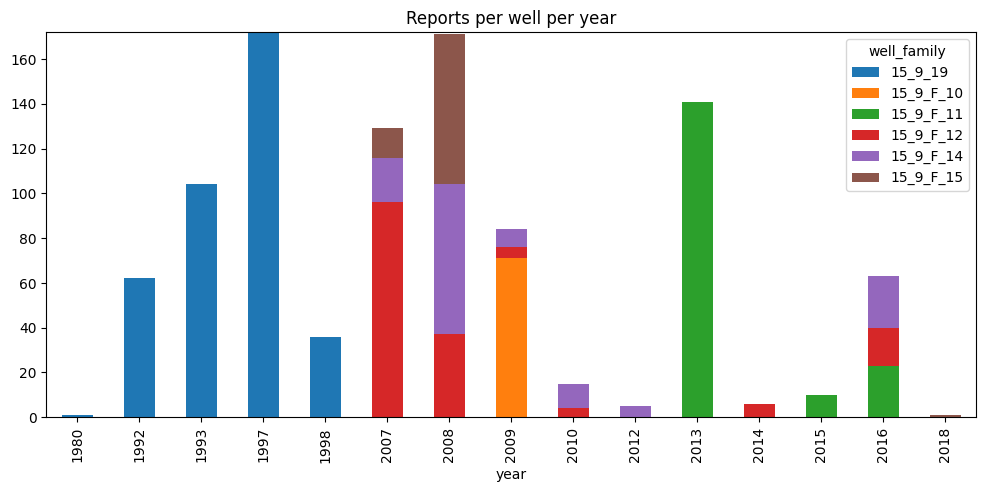

In [15]:
with get_connection(read_only=True) as con:
    df = con.execute("""
        SELECT well_family,
               EXTRACT(YEAR FROM report_date) AS year,
               COUNT(*) AS n
        FROM reports
        WHERE report_date IS NOT NULL
        GROUP BY well_family, year
        ORDER BY year, well_family
    """).df()

pivot = df.pivot(index="year", columns="well_family", values="n").fillna(0).astype(int)
pivot.plot(kind="bar", stacked=True, figsize=(12, 5), title="Reports per well per year")

## ✅ Task 1 done

If the cells above look reasonable, the database is ready for Task 2.

**Continue to:** `02_task2_matching.ipynb`